# Step 4: Feature Engineering

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor

df=pd.read_csv(r'C:\Users\sagar vitnor\OneDrive\Desktop\Data_analytics_pro\ad_campaign_cleaned_dataset (2).csv')


In [26]:

# 1️⃣ CTR आणि CVR derive करा
df['CTR'] = df['clicks'] / (df['impressions'] + 1e-6)  # Safe division
df['CVR'] = df['conversions'] / (df['clicks'] + 1e-6)

# 2️⃣ Business Based Feature: High Performing Device
df['High_Performing_Device'] = np.where(
    (df['CTR'] > df['CTR'].mean()) & 
    (df['device_type'].isin(['Mobile', 'Desktop'])),
    'Yes', 'No'
)

# 3️⃣ Validate: पहा 'CTR' आणि 'High_Performing_Device' कॉलम आलेत का
print(df[['CTR', 'device_type', 'High_Performing_Device']].head())


        CTR device_type High_Performing_Device
0  0.060064      Mobile                     No
1  0.148528     Desktop                    Yes
2  0.017390     Desktop                     No
3  0.182119     Desktop                    Yes
4  0.061428      Mobile                     No


## 4.1 बिझनेस बेस्ड Feature कल्पना (Ideation)

In [17]:
# उद्दिष्ट: मार्केटिंग व्यवसायाच्या दृष्टीने उपयुक्त फिचर्स सुचवणे.

# उदाहरणे:
# CTR_Category: High / Medium / Low based on CTR threshold.
# High_Performing_Device: if CTR > avg_ctr and device = Mobile/Desktop.

## 4.2 Derived Features (Transformation + Ratios)

In [27]:
df

,campaign_id,campaign_name,platform,date,week_of_year,impressions,clicks,cost,conversions,revenue,...,engagement_rate,ad_position,ad_spend_category,customer_acquisition_cost,customer_lifetime_value,campaign_objective,creative_type,CTR,CVR,High_Performing_Device
0,1001,New Year Bonanza,Instagram Ads,2024-01-01,4,19496,1171,243.16,225,4425.66,...,38,Top,High,1.08,440.59,Brand Awareness,Video,0.060064,0.192143,No
1,1002,Black Friday Deal,Google Ads,2024-01-02,36,15014,2230,487.70,206,3528.77,...,42,Bottom,Low,2.37,1577.28,Sales,Image,0.148528,0.092377,Yes
2,1003,Back to School,Google Ads,2024-01-03,52,36056,627,80.81,92,4141.91,...,41,Top,High,0.88,1803.58,Lead Generation,Image,0.017390,0.146730,No
3,1004,Diwali Dhamaka,Instagram Ads,2024-01-04,40,11196,2039,456.10,330,2776.98,...,52,Side,Medium,1.38,464.29,Lead Generation,Video,0.182119,0.161844,Yes
4,1005,Black Friday Deal,Facebook Ads,2024-01-05,39,22563,1386,179.69,202,4778.32,...,58,Side,Low,0.89,1784.99,Lead Generation,Image,0.061428,0.145743,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1996,Diwali Dhamaka,Twitter Ads,2026-09-22,20,42005,1314,391.74,222,3053.47,...,42,Side,Medium,1.76,737.46,Brand Awareness,Carousel,0.031282,0.168950,No
996,1997,Back to School,Facebook Ads,2026-09-23,37,17325,542,127.51,19,2990.73,...,45,Side,Medium,6.71,722.49,Lead Generation,Video,0.031284,0.035055,No
997,1998,Diwali Dhamaka,Google Ads,2026-09-24,16,23982,4311,151.11,146,1460.90,...,45,Side,High,1.04,1696.28,Sales,Image,0.179760,0.033867,Yes
998,1999,Summer Sale,Facebook Ads,2026-09-25,2,30375,4517,63.80,97,4191.23,...,57,Bottom,Medium,0.66,835.61,Sales,Video,0.148708,0.021474,Yes


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   campaign_id                1000 non-null   int64  
 1   campaign_name              1000 non-null   object 
 2   platform                   1000 non-null   object 
 3   date                       1000 non-null   object 
 4   week_of_year               1000 non-null   int64  
 5   impressions                1000 non-null   int64  
 6   clicks                     1000 non-null   int64  
 7   cost                       1000 non-null   float64
 8   conversions                1000 non-null   int64  
 9   revenue                    1000 non-null   float64
 10  ctr                        1000 non-null   float64
 11  cpc                        1000 non-null   float64
 12  conversion_rate            1000 non-null   float64
 13  roas                       1000 non-null   float6

In [20]:
df.columns

Index(['campaign_id', 'campaign_name', 'platform', 'date', 'week_of_year',
       'impressions', 'clicks', 'cost', 'conversions', 'revenue', 'ctr', 'cpc',
       'conversion_rate', 'roas', 'ad_type', 'audience_segment', 'device_type',
       'region', 'bounce_rate', 'avg_session_duration', 'engagement_rate',
       'ad_position', 'ad_spend_category', 'customer_acquisition_cost',
       'customer_lifetime_value', 'campaign_objective', 'creative_type'],
      dtype='object')

## 4.3 Categorical Encoding

## 4.5 Text Feature Profiling

## 4.6 Date-Time Feature Expansion

## 4.7 Segment-wise KPI Features

## 4.8 Skewness/Kurtosis Based Transformation

## 4.9 Feature Interactions

## 4.10 High Cardinality Simplification

## 4.11 Clustering (Optional Advanced)

## 4.12 select the important features

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   campaign_id                1000 non-null   int64  
 1   campaign_name              1000 non-null   object 
 2   platform                   1000 non-null   object 
 3   date                       1000 non-null   object 
 4   week_of_year               1000 non-null   int64  
 5   impressions                1000 non-null   int64  
 6   clicks                     1000 non-null   int64  
 7   cost                       1000 non-null   float64
 8   conversions                1000 non-null   int64  
 9   revenue                    1000 non-null   float64
 10  ctr                        1000 non-null   float64
 11  cpc                        1000 non-null   float64
 12  conversion_rate            1000 non-null   float64
 13  roas                       1000 non-null   float6


Top 20 Important Features:

CTR                           0.200316
ctr                           0.187635
sqrt_clicks                   0.098935
clicks                        0.089750
CVR                           0.061734
cpc                           0.057239
conversion_rate               0.055428
log_impressions               0.030822
impressions                   0.028369
High_Performing_Device_Yes    0.018134
customer_acquisition_cost     0.009884
customer_lifetime_value       0.009518
roas                          0.009440
revenue                       0.008950
log_revenue                   0.008851
log_cost                      0.008639
conversions                   0.008487
week_of_year                  0.007902
bounce_rate                   0.007783
cost                          0.007007
dtype: float64

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       182
         Low       1.00      1.00      1.0

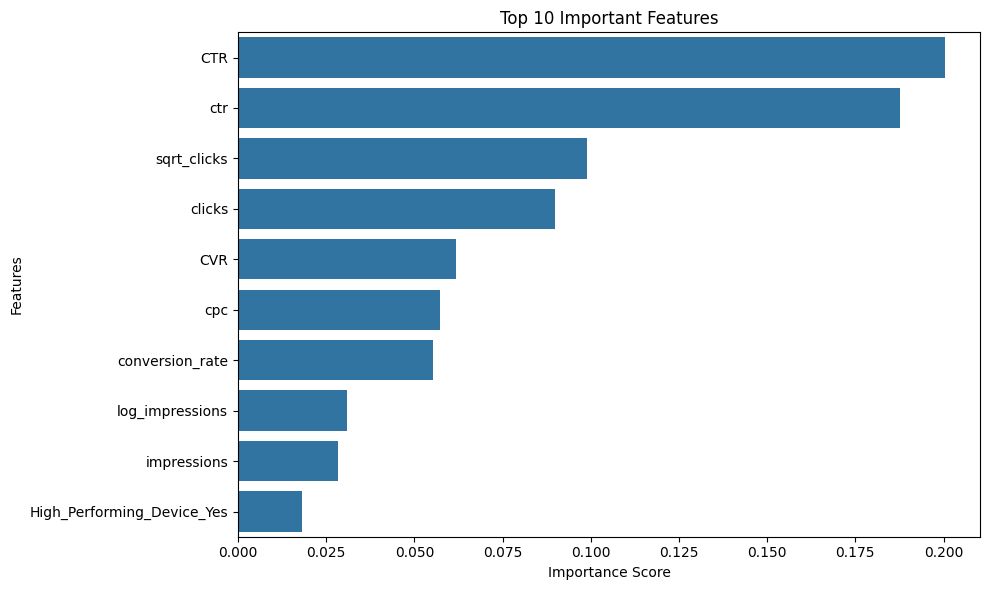

In [ ]:
# ---------------------------------------
# Step 0: Import Libraries
# ---------------------------------------
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------
# Step 1: Load the Data
# ---------------------------------------
df = pd.read_csv(r'C:\Users\sagar vitnor\OneDrive\Desktop\Data_analytics_pro\ad_campaign_cleaned_dataset (2).csv')

# ---------------------------------------
# Step 2: Basic Derived Features
# ---------------------------------------
df['CTR'] = df['clicks'] / df['impressions'].replace(0, np.nan)
df['CVR'] = df['conversions'] / df['clicks'].replace(0, np.nan)
df['CTR_Category'] = pd.cut(df['CTR'], bins=[0, 0.01, 0.05, 1], labels=['Low', 'Medium', 'High'])

# ---------------------------------------
# Step 3: Business-Based Feature Ideation
# ---------------------------------------
df['High_Performing_Device'] = np.where(
    (df['CTR'] > df['CTR'].mean()) & (df['device_type'].isin(['Mobile', 'Desktop'])),
    'Yes', 'No'
)

df['ROAS_Category'] = pd.cut(df['roas'], bins=[-np.inf, 1, 2, np.inf], labels=['Low', 'Medium', 'High'])

# ---------------------------------------
# Step 4: Advanced Feature Engineering
# ---------------------------------------

# 4.2 Transformation Features
df['log_impressions'] = np.log1p(df['impressions'])
df['sqrt_clicks'] = np.sqrt(df['clicks'])

# 4.6 Date Feature Expansion
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# 4.7 Segment-wise KPI
segment_ctr = df.groupby('audience_segment')['CTR'].transform('mean')
df['segment_avg_ctr'] = segment_ctr

# 4.8 Skewness/Kurtosis Based Transformations
df['log_cost'] = np.log1p(df['cost'])
df['log_revenue'] = np.log1p(df['revenue'])

# ---------------------------------------
# Step 5: Feature Selection using Random Forest
# ---------------------------------------

# Target Variable: Drop NA rows for modeling
df = df.dropna(subset=['CTR_Category'])

# Drop irrelevant or high-cardinality columns (IDs, names, raw dates)
drop_cols = ['campaign_id', 'campaign_name', 'date']
df_model = df.drop(columns=drop_cols, errors='ignore')

# Separate X and y
X = df_model.drop(['CTR_Category'], axis=1)
y = df_model['CTR_Category']

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Ensure all features are numeric and clean
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Feature Importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Show Top Features
print("\nTop 20 Important Features:\n")
print(importances.head(20))

# Classification Report (optional)
y_pred = rf.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ---------------------------------------
# Step 6: Visualization (Optional)
# ---------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(10), y=importances.head(10).index)
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
